In [ ]:
from scipy import signal as sig
import numpy as np
import matplotlib.pyplot as plt 
import scipy.io as sio
from scipy.io.wavfile import write
from numbers import Integral
from numbers import Real

%matplotlib widget


# CONSIGNA

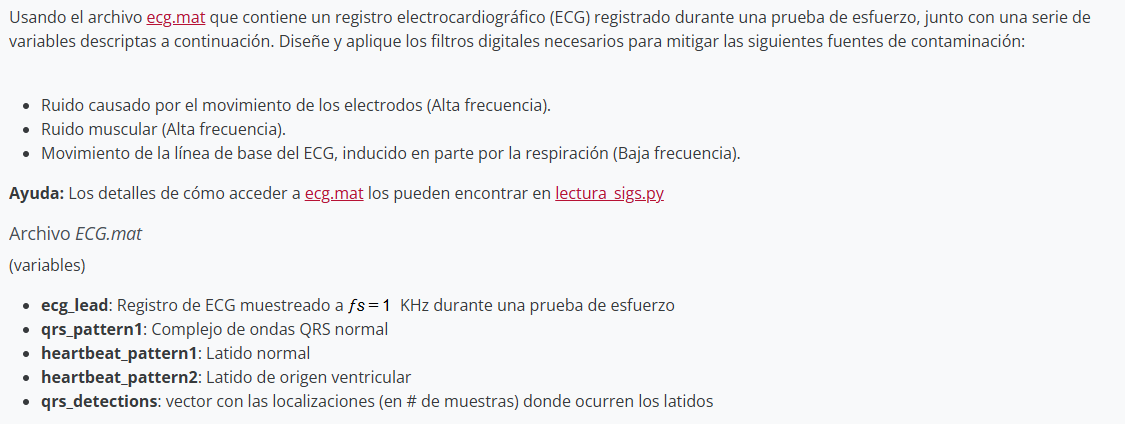
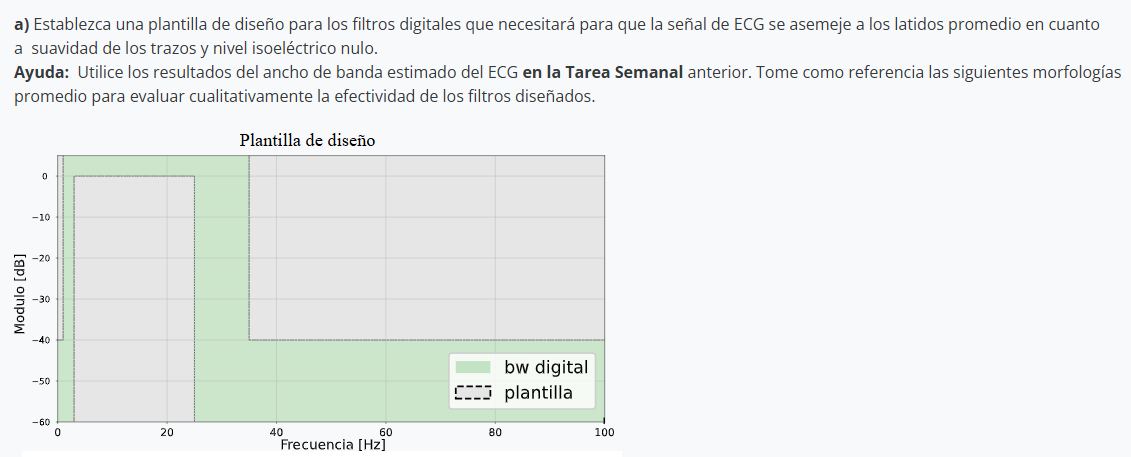
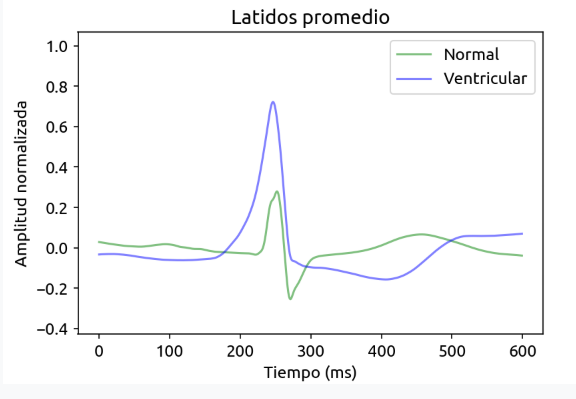
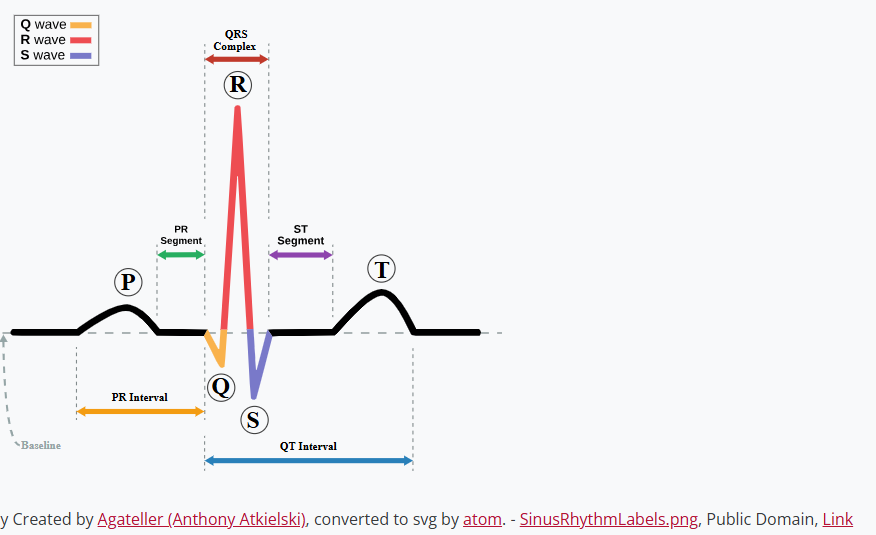
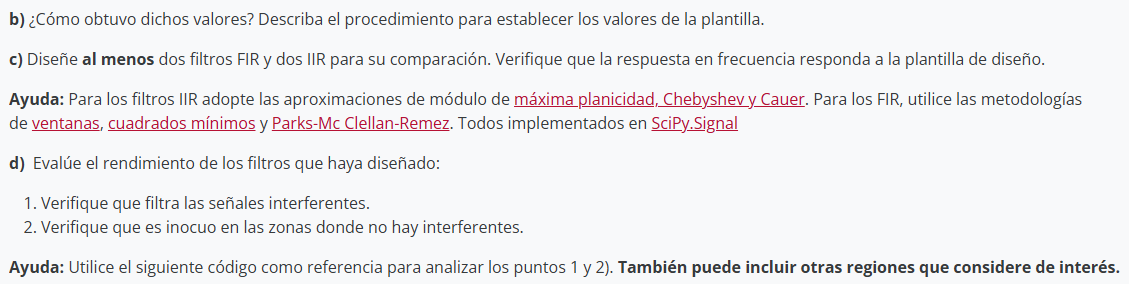

# Funciones

In [ ]:
def plot_pzmap(z, p, *args, **kwargs):
    fig, ax = plt.subplots(*args, **kwargs)
    plt.scatter(np.real(z), np.imag(z), color='b', marker='o')
    plt.scatter(np.real(p), np.imag(p), color='r', marker='x')
    circle = plt.Circle((0,0), 1, fill=False)
    ax.add_patch(circle)
    ax.set_xlim((-1.1, 1.1))
    ax.set_ylim((-1.1, 1.1))

    ax.axhline(0, color='black')
    ax.axvline(0, color='black')
    plt.grid(True, which='both', ls='--')
    plt.title('Polos y Ceros del Filtro')
    plt.ylabel('Real')
    plt.xlabel('Imaginario')
    plt.gca().set_aspect('equal', adjustable='box')
    plt.tight_layout()
    return fig, ax

def plot_filt_mag(w, H, title='Filtro', ax=None, label=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(10,8))

    mag = 20*np.log10(np.maximum(np.abs(H), 1e-13))
    ax.plot(w, mag, label=label)
    ax.set_title(f'{title} - Respuesta en amplitud')
    ax.set_ylabel('Magnitud [dB]')
    ax.set_xlabel('Frecuencia [Hz]')
    ax.grid(True, which='both', ls='--')

    if label is not None:
        ax.legend()

    return ax


def plot_filt_phase(w, H, title='Filtro', ax=None, label=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(10,8))

    phase = np.unwrap(np.angle(H))
    ax.plot(w, phase, label=label)
    ax.set_title(f'{title} - Respuesta en fase')
    ax.set_ylabel('Fase [rad]')
    ax.set_xlabel('Frecuencia [Hz]')
    ax.grid(True, which='both', ls='--')

    if label is not None:
        ax.legend()

    return ax


def plot_filt_delay(w, H, title='Filtro', ax=None, label=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(10,8))

    phase = np.unwrap(np.angle(H))
    gd = -np.diff(phase)/(2*np.pi*np.diff(w))
    gd = np.append(gd, gd[-1])

    ax.plot(w, gd, label=label)
    ax.set_title(f'{title} - Retardo de grupo')
    ax.set_ylabel('Retardo [s]')
    ax.set_xlabel('Frecuencia [Hz]')
    ax.grid(True, which='both', ls='--')

    if label is not None:
        ax.legend()

    return ax

def plot_filt_resp(w, H, title='Filtro', ax=None, label=None):
    if ax is None:
        _, ax = plt.subplots(3, 1, figsize=(10,8))

    plot_filt_mag(w, H, title, ax[0], label)
    plot_filt_phase(w, H, title, ax[1], label)
    plot_filt_delay(w, H, title, ax[2], label)

    return ax


def plot_plantilla(filter_type='', fpass=0.25, ripple=0.5, fstop=0.6, attenuation=40, fs=2):
    """
    Plotea una plantilla de diseño de filtro digital.

    Parameters
    -----------
    filter_type : str, opcional
        Tipo de filtro ('lowpass', 'highpass', 'bandpass', 'bandstop'). Por defecto es 'lowpass'.
    fpass : float o tupla, opcional
        Frecuencia de paso o tupla de frecuencias de paso para los filtros 'bandpass' o 'bandstop'.
    ripple : float, opcional
        Máxima ondulación en la banda de paso (en dB). Por defecto es 0.5 dB.
    fstop : float o tupla, opcional
        Frecuencia de detención o tupla de frecuencias de detención para los filtros 'bandpass' o 'bandstop'.
    attenuation : float, opcional
        Atenuación mínima en la banda de detención (en dB). Por defecto es 40 dB.
    fs : float, opcional
        Frecuencia de muestreo. Por defecto es 2.
        
    Returns
    --------
    None


    Raises
    ------
    ValueError
        Si los argumentos no son del tipo o valor correcto.
    

    See Also
    -----------
    :func:`analyze_sys`

    
    Example
    --------
    >>> # Analiza un sistema con w0 = 1 rad/s y Q = sqrt(2)/2
    >>> import numpy as np
    >>> from scipy import signal as sig
    >>> import matplotlib.pyplot as plt
    >>> from pytc2.sistemas_lineales import bodePlot, plot_plantilla
    >>> Q = np.sqrt(2)/2
    >>> w0 = 1
    >>> num = np.array([w0**2])
    >>> den = np.array([1., w0 / Q, w0**2])
    >>> H1 = sig.TransferFunction(num, den)
    >>> fig_id, axes_hdl = bodePlot(H1, fig_id=1, axes_hdl='none', filter_description='Filtro pasa bajos', worN=1000, digital=False, xaxis='omega', fs=2*np.pi)
    >>> plt.sca(axes_hdl[0])
    >>> plot_plantilla(filter_type='lowpass', fpass=1.0, ripple=3, fstop=3.0, attenuation=20, fs=2)

    """

    if not isinstance(fpass, (tuple, np.ndarray, Integral, Real)):
        raise ValueError("fpass debe ser un float o una tupla de frecuencias de paso.")
    
    if not isinstance(fstop, (tuple, np.ndarray, Integral, Real)):
        raise ValueError("fstop debe ser un float o una tupla de frecuencias de detención.")
    
    if not isinstance(attenuation, (tuple, np.ndarray, Integral, Real)):
        try:
            attenuation = np.float64(attenuation)
        except ValueError:
            raise ValueError("attenuation debe ser un valor numérico o convertible a float.")    
    
    if not isinstance(ripple, (tuple, np.ndarray, Integral, Real)):
        try:
            ripple = np.float64(ripple)
        except ValueError:
            raise ValueError("attenuation debe ser un valor numérico o convertible a float.")    
    
    if not isinstance(fs, (Integral, Real)):
        try:
            fs = np.float64(fs)
        except ValueError:
            raise ValueError("fs debe ser un valor numérico o convertible a float.")    

    # Obtener los límites actuales de los ejes
    xmin, xmax, ymin, ymax = plt.axis()

    # Banda de paso digital
    plt.fill([xmin, xmin, fs / 2, fs / 2], [ymin, ymax, ymax, ymin], 'lightgreen', alpha=0.2, lw=1, label='Banda de paso digital')

    # analizar los valores de la plantilla para ver qué tipo de plantilla es
    tipos_permitidos = ['lowpass', 'highpass', 'bandpass', 'bandstop']
    if filter_type not in tipos_permitidos:
            
        if isinstance(fpass, (tuple, np.ndarray)) and isinstance(fstop, (tuple, np.ndarray)):
            if fstop[0] < fpass[0]:
                filter_type = 'bandpass'
            else:                
                filter_type = 'bandstop'
        else:
            if fstop < fpass:
                filter_type = 'highpass'
            else:                
                filter_type = 'lowpass'

    if filter_type == 'lowpass':
        # Definir regiones de banda de detención y banda de paso para el filtro pasa bajos
        fstop_start = fstop
        fstop_end = xmax
        fpass_start = xmin
        fpass_end = fpass
    elif filter_type == 'highpass':
        # Definir regiones de banda de detención y banda de paso para el filtro pasa altos
        fstop_start = xmin
        fstop_end = fstop
        fpass_start = fpass
        fpass_end = xmax
    elif filter_type == 'bandpass':
        if len(fpass) == 2 and len(fstop) == 2:
            fstop_start = xmin
            fstop_end = fstop[0]
            fpass_start = fpass[0]
            fpass_end = fpass[1]
            fstop2_start = fstop[1]
            fstop2_end = xmax
        else:
            raise ValueError("En modo bandpass, fpass y fstop deben ser tuplas con 2 valores.")
    elif filter_type == 'bandstop':
        if len(fpass) == 2 and len(fstop) == 2:
            fpass_start = xmin
            fpass_end = fpass[0]
            fstop_start = fstop[0]
            fstop_end = fstop[1]
            fpass2_start = fpass[1]
            fpass2_end = xmax
        else:
            raise ValueError("En modo bandstop, fpass y fstop deben ser tuplas con 2 valores.")
    else:
        raise ValueError("filtro_type debe ser 'lowpass', 'highpass', 'bandpass', o 'bandstop'.")

    # Plotea regiones de banda de detención y banda de paso
    plt.fill([fstop_start, fstop_end, fstop_end, fstop_start], [-attenuation, -attenuation, ymax, ymax], 'lightgrey', alpha=0.4, hatch='x', lw=1, ls='--', ec='k')
    plt.fill([fpass_start, fpass_start, fpass_end, fpass_end], [ymin, -ripple, -ripple, ymin], 'lightgrey', alpha=0.4, hatch='x', lw=1, ls='--', ec='k', label='Plantilla')
    
    # Plotea región adicional de banda de detención para filtro pasa banda
    if filter_type == 'bandpass':
        plt.fill([fstop2_start, fstop2_end, fstop2_end, fstop2_start], [-attenuation, -attenuation, ymax, ymax], 'lightgrey', alpha=0.4, hatch='x', lw=1, ls='--', ec='k')
    
    # Plotea región adicional de banda de paso para filtro rechaza banda
    if filter_type == 'bandstop':
        plt.fill([fpass2_start, fpass2_start, fpass2_end, fpass2_end], [ymin, -ripple, -ripple, ymin], 'lightgrey', alpha=0.4, hatch='x', lw=1, ls='--', ec='k')
    
    # Establece los límites de los ejes
    plt.axis([xmin, xmax, np.max([ymin, -100]), np.max([ymax, 1])])


# Señal

Señal de ECG con una frecuencia de muestreo de 1KHz tomada de un alumno. Presenta 2 zonas específicas denominadas heartbeat_pattern1 y heartbeat_pattern2

In [ ]:
# Lectura de ECG #
fs = 1000 # Hz

# para listar las variables que hay en el archivo
#sio.whosmat('ECG_TP4.mat')
mat_struct = sio.loadmat('./ECG_TP4.mat')

ecg_one_lead = mat_struct['ecg_lead'].flatten()
cant_muestras = len(ecg_one_lead)

hb_1 = mat_struct['heartbeat_pattern1'].flatten()
hb_2 = mat_struct['heartbeat_pattern2'].flatten()

plt.figure(figsize=(10,8))
plt.subplot(3,1,1)
plt.plot(ecg_one_lead[5000:12000])
plt.grid()

plt.subplot(3,1,2)
plt.plot(hb_1)
plt.grid()

plt.subplot(3,1,3)
plt.plot(hb_2)
plt.grid()

plt.tight_layout()
plt.show()
